# Medical Appointment No-Show Exploratory Data Analysis

An exploratory analysis of ~110,000 medical appointment records from Brazil, investigating which patient, appointment, and neighborhood characteristics are associated with patients missing ("no-showing") their scheduled appointments.

## 1. Introduction

**Dataset:** Medical appointment records including patient demographics (gender, age), health conditions (hypertension, diabetes, alcoholism, handicap status), socioeconomic status (scholarship), appointment logistics (scheduled date, appointment date, SMS reminders), and the outcome of interest, `No-show`.

**Objective:** Identify which factors are associated with a patient missing their appointment. This is an exploratory analysis, the goal is to surface patterns and associations worth flagging, not to build a predictive model or establish causal relationships.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

PALETTE = "Blues_d"


def annotate_vertical_bars(ax, fmt="{:.1%}", pad=0.002):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height + pad),
            ha="center",
            va="bottom",
            fontsize=9
        )

## 2. Data Overview and Quality

In [39]:
df = pd.read_csv('medical_noshow_data.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [40]:
df.shape

(110527, 14)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [42]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [43]:
df.nunique()

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

**Summary so far:** 110,527 appointments, 14 columns, no missing values and no duplicate rows at the raw level. Next, checking for values that are technically present but logically invalid.

In [45]:
# Age has a small number of invalid values
age_counts = df['Age'].value_counts(normalize=True).reset_index()
age_counts[age_counts['Age'] < 0]

,Age,proportion
103,-1,0.000009


One appointment has `Age = -1`, an impossible value. It affects a single row (~0.001% of the dataset), so it's converted to a missing value rather than dropped or guessed at.

In [46]:
df['Age'] = df['Age'].replace(-1, np.nan)
df['Age'].isnull().sum()

np.int64(1)

In [47]:
# Checking the upper end of the age range too
df[df['Age'] > 100][['Age']].describe()

,Age
count,7.000000
mean,111.285714
std,6.343350
min,102.000000
25%,108.500000
50%,115.000000
75%,115.000000
max,115.000000


In [48]:
df = df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap'
})

df[['ScheduledDay', 'AppointmentDay']].dtypes

ScheduledDay      str
AppointmentDay    str
dtype: object

In [49]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['WaitingDays'] = (
    df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()
).dt.days

df['WaitingDays'].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

In [50]:
df[df['WaitingDays'] < 0][['ScheduledDay', 'AppointmentDay', 'WaitingDays']]

,ScheduledDay,AppointmentDay,WaitingDays
27033,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1
55226,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1
64175,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1
71533,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6
72362,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1


Five appointments have a negative waiting time, the scheduled date falls after the appointment date, which logically isn't possible. These are set to missing rather than dropped, since the rest of each row is still usable for other analyses.

In [51]:
df.loc[df['WaitingDays'] < 0, 'WaitingDays'] = np.nan
df['WaitingDays'].describe()

count    110522.000000
mean         10.184253
std          15.255115
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

In [52]:
bins = [-1, 17, 29, 44, 59, 74, 120]
labels = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# The single missing Age value produces one missing Age_Group
df['Age_Group'].isna().sum()

np.int64(1)

In [53]:
bins = [-1, 0, 7, 14, 30, 60, 179]
labels = ['Same Day', '1-7 days', '8-14 days', '15-30 days', '31-60 days', '61-179 days']

df['Waiting_Group'] = pd.cut(df['WaitingDays'], bins=bins, labels=labels)
df['Waiting_Group'].value_counts().sort_index()

Waiting_Group
Same Day       38563
1-7 days       32185
8-14 days      12025
15-30 days     17371
31-60 days      8283
61-179 days     2095
Name: count, dtype: int64

**Data quality summary:**
- 110,527 rows, no missing values or duplicates in the raw data.
- One invalid `Age = -1` value -> converted to missing (negligible, 1 row).
- Five appointments with a negative waiting time (scheduled after the appointment date) -> converted to missing (negligible, 5 rows).
- These two issues together produce one missing `Age_Group` value.
- `Handicap` is coded 0–4; only 0 and 1 are common, and the dataset documentation doesn't clarify what levels 2–4 specifically represent.

## 3. Overall Appointment Attendance

`No-show = No` means the patient **attended**; `No-show = Yes` means the patient **missed** the appointment.

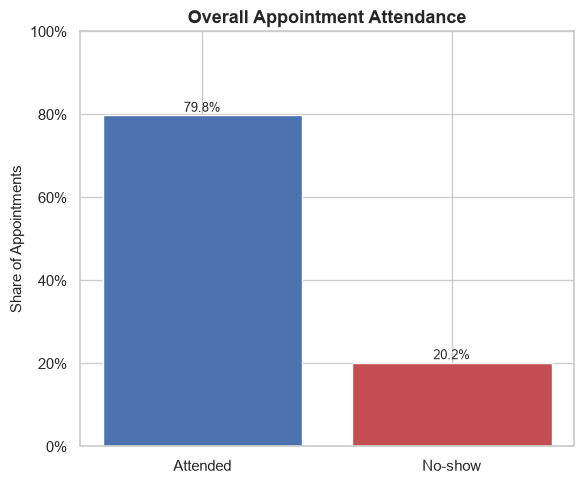

In [54]:
overall = df['No-show'].value_counts(normalize=True).reindex(['No', 'Yes'])

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    ['Attended', 'No-show'],
    overall.values,
    color=['#4C72B0', '#C44E52']
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Overall Appointment Attendance')
ax.set_ylabel('Share of Appointments')
ax.set_ylim(0, 1)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

About 80% of appointments were attended and 20% resulted in a no-show. This ~1-in-5 baseline rate is the benchmark for evaluating whether any given factor below is associated with a meaningfully higher or lower no-show rate.

## 4. Demographic Factors

### Gender

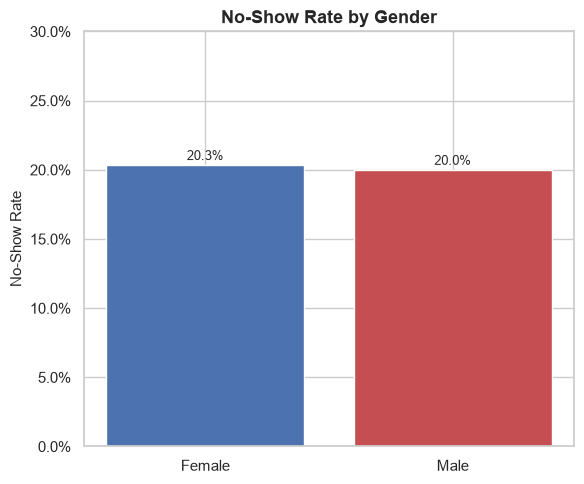

In [55]:
gender_noshow = (
    df.groupby('Gender')['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    ['Female', 'Male'],
    gender_noshow.reindex(['F', 'M']).values,
    color=['#4C72B0', '#C44E52']
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Gender')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, 0.3)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

Gender shows little association with attendance: about 20.3% of female patients and 20.0% of male patients missed their appointments, a difference that's under one percentage point. Note that the dataset itself is imbalanced (about 65% female, 35% male), but that imbalance doesn't translate into a meaningful difference in no-show behavior.

### Age and Age Groups

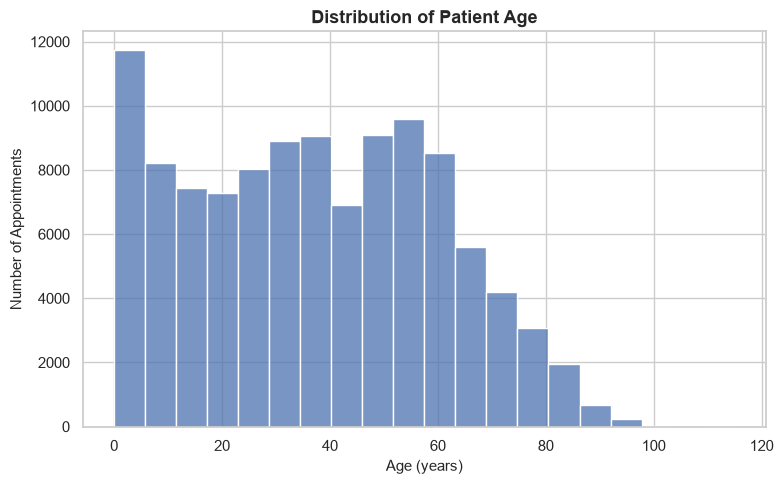

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=20, ax=ax, color='#4C72B0')
ax.set_title('Distribution of Patient Age')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Appointments')
plt.tight_layout()
plt.show()

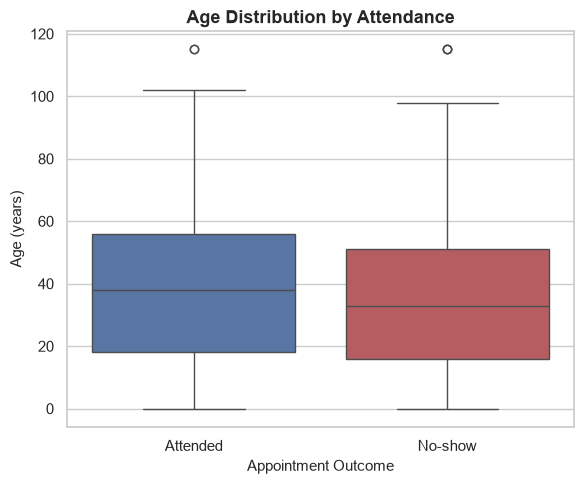

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=df,
    x='No-show',
    y='Age',
    order=['No', 'Yes'],
    hue='No-show',
    palette=['#4C72B0', '#C44E52'],
    legend=False,
    ax=ax
)

ax.set_title('Age Distribution by Attendance')
ax.set_xlabel('Appointment Outcome')
ax.set_ylabel('Age (years)')

# Change the displayed labels WITHOUT changing their order
ax.set_xticks([0, 1])
ax.set_xticklabels(['Attended', 'No-show'])

plt.tight_layout()
plt.show()

Age shows a weak association with attendance at the individual level, the no-show group is only slightly younger on average, and the two distributions overlap substantially. The pattern becomes clearer once age is grouped into bands.

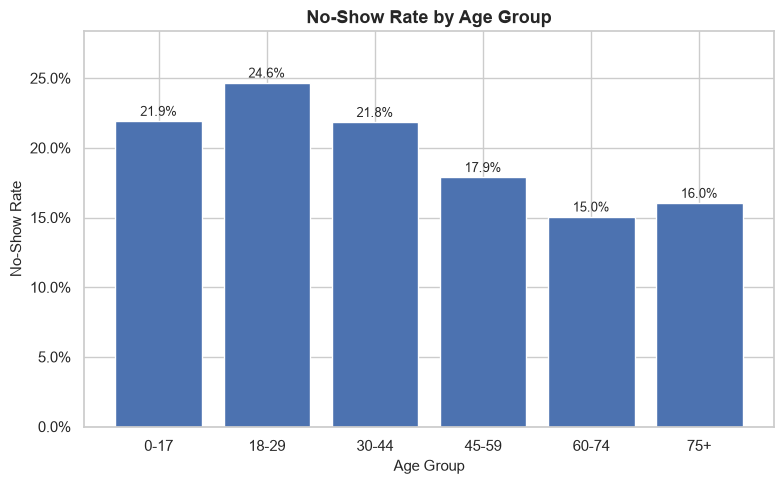

In [58]:
age_noshow = (
    df.groupby('Age_Group', observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    age_noshow.index.astype(str),
    age_noshow.values,
    color='#4C72B0'
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, max(age_noshow.values) * 1.15)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

Patients aged 18–29 had the highest no-show rate at approximately 24.6%, compared with approximately 15–18% among patients aged 45 and older. This iis roughly an 8–9 percentage-point gap between the youngest adult group and the older adult groups. This suggests younger adults are somewhat more likely to miss scheduled appointments.

## 5. Health and Socioeconomic Factors

### Hypertension, Diabetes, Alcoholism

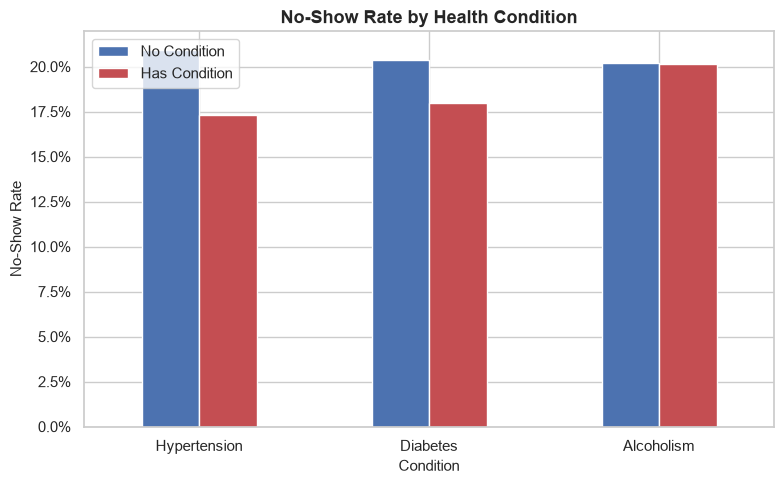

In [59]:
conditions = ['Hypertension', 'Diabetes', 'Alcoholism']
condition_rates = pd.Series({
    c: df.groupby(c)['No-show'].value_counts(normalize=True).unstack()['Yes']
    for c in conditions
})

# condition_rates holds, for each condition, the No-show=Yes rate indexed by 0/1
plot_df = pd.DataFrame({c: condition_rates[c] for c in conditions}).T
plot_df.columns = ['No Condition', 'Has Condition']

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Health Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('No-Show Rate')
ax.set_xticklabels(plot_df.index, rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

Hypertension shows a modest association: patients with hypertension had a no-show rate about 3.6 percentage points *lower* than patients without it (17.3% vs 20.9%). Diabetes shows a similar small gap (18.0% vs 20.4%). Alcoholism shows essentially no difference (20.1% vs 20.1%). Overall, these health conditions show relatively weak standalone associations with appointment attendance.

### Handicap

In [60]:
handicap_counts = df['Handicap'].value_counts().sort_index()
handicap_rate = df.groupby('Handicap')['No-show'].value_counts(normalize=True).unstack()['Yes']

summary = pd.DataFrame({'Appointments': handicap_counts, 'No-Show Rate': handicap_rate})
summary

,Appointments,No-Show Rate
Handicap,,
0,108286,0.202353
1,2042,0.179236
2,183,0.202186
3,13,0.230769
4,3,0.333333


`Handicap` is coded from 0–4, but only levels 0 (97.97%) and 1 (1.85%) have meaningful sample sizes. Levels 2, 3, and 4 together account for only about 0.18% of appointments (183, 13, and 3 observations, respectively). No-show rates appear to increase at levels 3 (23.1%) and 4 (33.3%), but these estimates are extremely unstable because of the very small sample sizes and should not be treated as reliable evidence of a relationship. The dataset documentation also does not clearly define what levels 2–4 represent beyond indicating a "handicap level," so no further interpretation is attempted.

### Scholarship

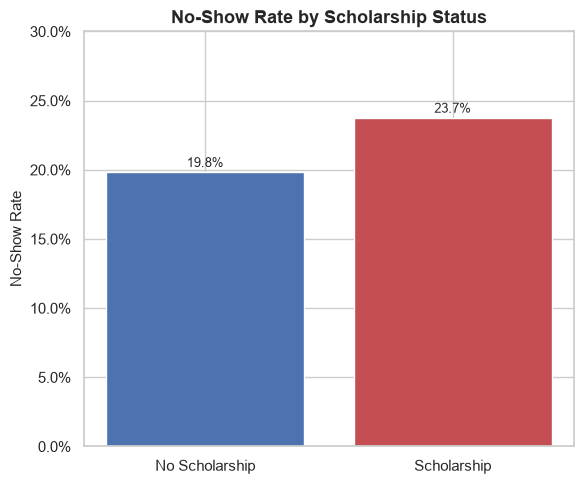

In [61]:
scholarship_noshow = (
    df.groupby('Scholarship')['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    ['No Scholarship', 'Scholarship'],
    scholarship_noshow.reindex([0, 1]).values,
    color=['#4C72B0', '#C44E52']
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Scholarship Status')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, 0.3)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

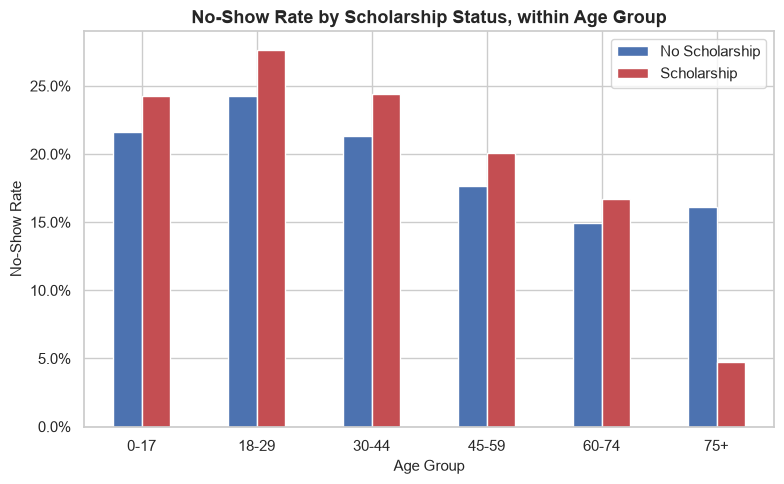

In [62]:
age_scholarship = (
    df.groupby(['Age_Group', 'Scholarship'], observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
    .unstack()
)
age_scholarship.columns = ['No Scholarship', 'Scholarship']

fig, ax = plt.subplots(figsize=(8, 5))
age_scholarship.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Scholarship Status, within Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('No-Show Rate')
ax.set_xticklabels(age_scholarship.index.astype(str), rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

Scholarship recipients had a no-show rate of about 23.7%, compared with 19.8% for non-recipients, a gap of roughly 4 percentage points. Scholarship recipients also skew younger on average (30.6 years vs. 37.8 years), which raised the question of whether this difference could simply reflect age. Breaking the comparison down within each age group shows that the gap persists across nearly every age band, typically by 2–3 percentage points; the 75+ group is the exception. Therefore, age alone does not appear to explain the pattern. The dataset does not include enough information (e.g., income or distance to the clinic) to determine why this association exists, so it should be interpreted as a modest association rather than a causal relationship.

## 6. Appointment Characteristics

### Waiting Time

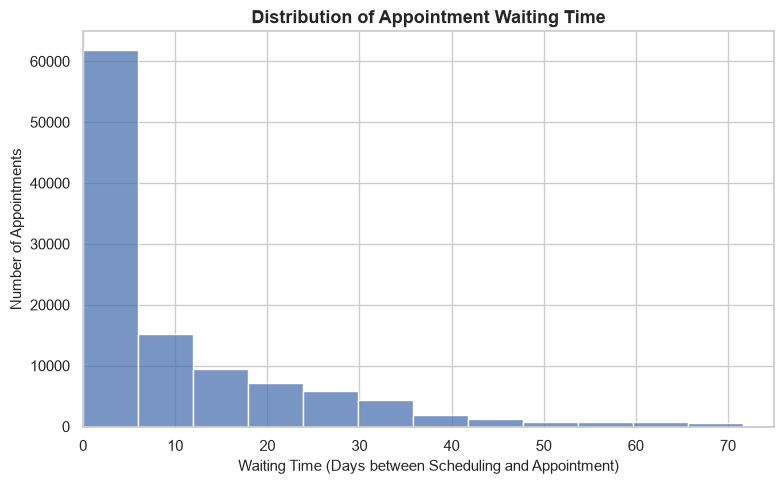

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='WaitingDays', bins=30, ax=ax, color='#4C72B0')
ax.set_xlim(0, 75)
ax.set_title('Distribution of Appointment Waiting Time')
ax.set_xlabel('Waiting Time (Days between Scheduling and Appointment)')
ax.set_ylabel('Number of Appointments')
plt.tight_layout()
plt.show()

Waiting time is strongly right-skewed: the mean is 10.2 days but the median is only 4 days, meaning most appointments are scheduled with a short lead time while a smaller number wait much longer.

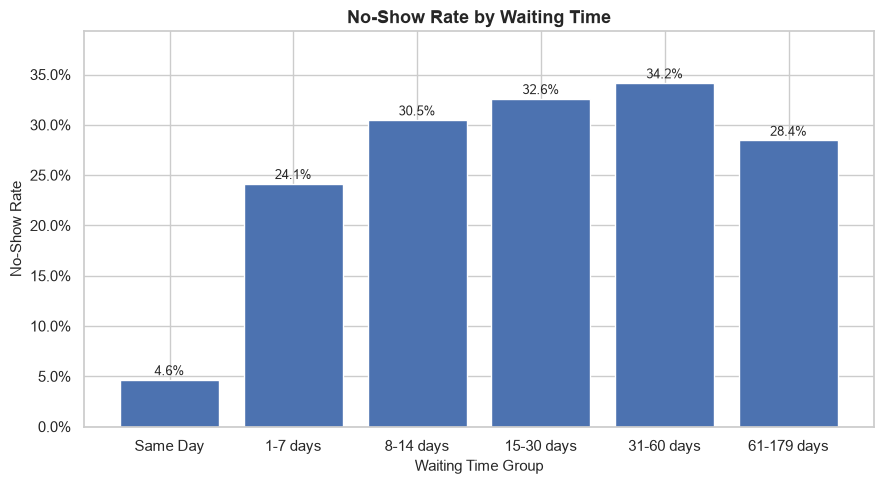

In [64]:
waiting_noshow = (
    df.groupby('Waiting_Group', observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    waiting_noshow.index.astype(str),
    waiting_noshow.values,
    color='#4C72B0'
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Waiting Time')
ax.set_xlabel('Waiting Time Group')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, max(waiting_noshow.values) * 1.15)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

Waiting time shows one of the strongest associations in the dataset. Same-day appointments have a no-show rate of just 4.6% (about 95% attendance), rising steadily to 34.2% for appointments booked 31–60 days out. The 61–179 day group dips back down to 28.4%, an exception to the overall trend, but it still represents over 2,000 appointments, so it is a real pattern rather than pure noise, just a less extreme one than the 31–60 day group. Patients who missed their appointment had a median wait of 11 days, compared with 2 days for patients who attended.

### SMS Reminders

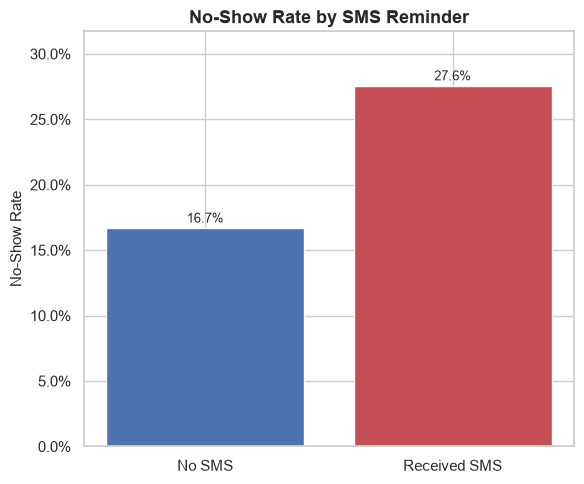

In [28]:
sms_noshow = (
    df.groupby('SMS_received')['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    ['No SMS', 'Received SMS'],
    sms_noshow.reindex([0, 1]).values,
    color=['#4C72B0', '#C44E52']
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by SMS Reminder')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, max(sms_noshow.values) * 1.15)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

On the surface, this looks like a strong and counterintuitive association: patients who received an SMS reminder had a higher no-show rate (27.6%) than those who did not (16.7%). However, SMS receipt is not randomly assigned. Same-day appointments never receive an SMS reminder because there is no time to send one, so SMS recipients are structurally weighted toward longer waiting times. Longer waiting times are strongly associated with higher no-show rates, so this relationship needs to be examined while accounting for waiting time before drawing conclusions about the effect of SMS itself.

In [29]:
sms_wait = df.groupby('SMS_received')['WaitingDays'].describe()[['mean', '50%']]
sms_wait.columns = ['Mean Waiting Days', 'Median Waiting Days']
sms_wait

,Mean Waiting Days,Median Waiting Days
SMS_received,,
0,6.007902,0.0
1,19.016713,14.0


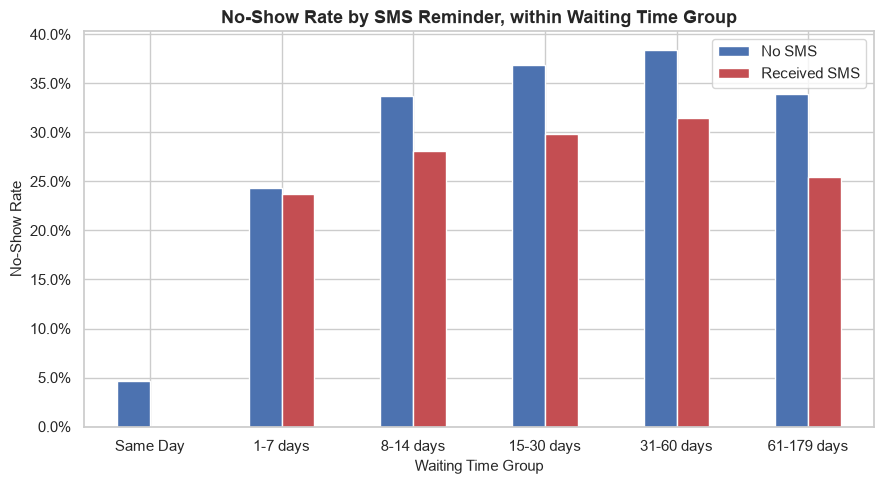

In [30]:
sms_by_waiting = (
    df.groupby(['Waiting_Group', 'SMS_received'], observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
    .unstack()
)
sms_by_waiting.columns = ['No SMS', 'Received SMS']

fig, ax = plt.subplots(figsize=(9, 5))
sms_by_waiting.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by SMS Reminder, within Waiting Time Group')
ax.set_xlabel('Waiting Time Group')
ax.set_ylabel('No-Show Rate')
ax.set_xticklabels(sms_by_waiting.index.astype(str), rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

Confirmed: SMS recipients have a median wait of 14 days compared with 0 days for non-recipients (mean 19.0 vs. 6.0 days). Once waiting time is held roughly constant, the relationship reverses within every waiting-time band. Patients who received an SMS had a lower no-show rate than those who did not, such as 28.1% vs. 33.8% in the 8–14 day group. This is a good example of a confounding effect. The raw SMS comparison was influenced by waiting time rather than necessarily reflecting the effect of the SMS itself. Because this is observational data, it still does not prove that SMS reminders cause better attendance, but the direction of the raw comparison was misleading, and the within-group comparison is much more informative.

### Appointment Day of Week

In [31]:
df['Appointment_DayOfWeek'] = df['AppointmentDay'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Appointment_DayOfWeek'] = pd.Categorical(df['Appointment_DayOfWeek'], categories=day_order, ordered=True)

df['Appointment_DayOfWeek'].value_counts().sort_index()

Appointment_DayOfWeek
Monday       22715
Tuesday      25640
Wednesday    25867
Thursday     17247
Friday       19019
Saturday        39
Sunday           0
Name: count, dtype: int64

There are zero Sunday appointments and only 39 Saturday appointments, there aren't enough appointments to treat Saturday as a meaningful weekday trend. The chart below is restricted to Monday–Friday, which cover the vast majority of appointments.

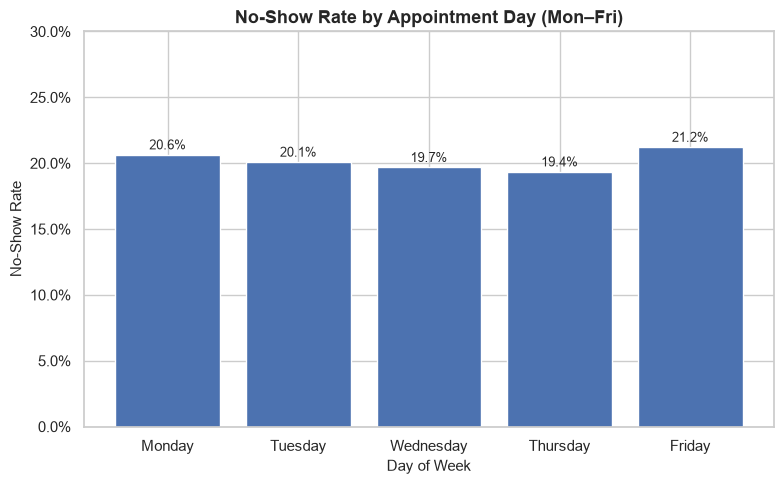

In [32]:
weekday_noshow = (
    df[df['Appointment_DayOfWeek'].isin(day_order[:5])]
    .groupby('Appointment_DayOfWeek', observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    weekday_noshow.index.astype(str),
    weekday_noshow.values,
    color='#4C72B0'
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Appointment Day (Mon–Fri)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, 0.3)

annotate_vertical_bars(ax)

plt.tight_layout()
plt.show()

Weekday no-show rates have a two-percentage-point spread, ranging from about 19.4% (Thursday) to 21.2% (Friday). Day of week appears to have little association with attendance.

## 7. Neighborhood Analysis

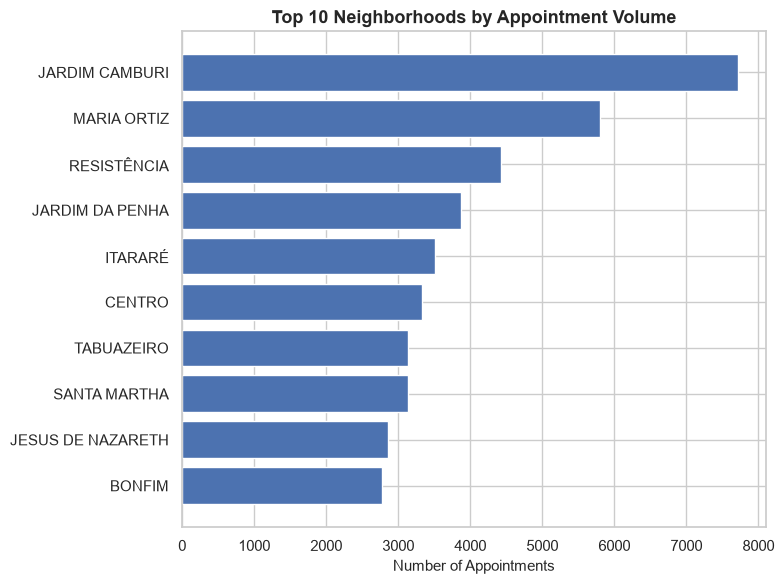

In [33]:
top_volume = df['Neighbourhood'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_volume.index, top_volume.values, color='#4C72B0')
ax.set_title('Top 10 Neighborhoods by Appointment Volume')
ax.set_xlabel('Number of Appointments')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

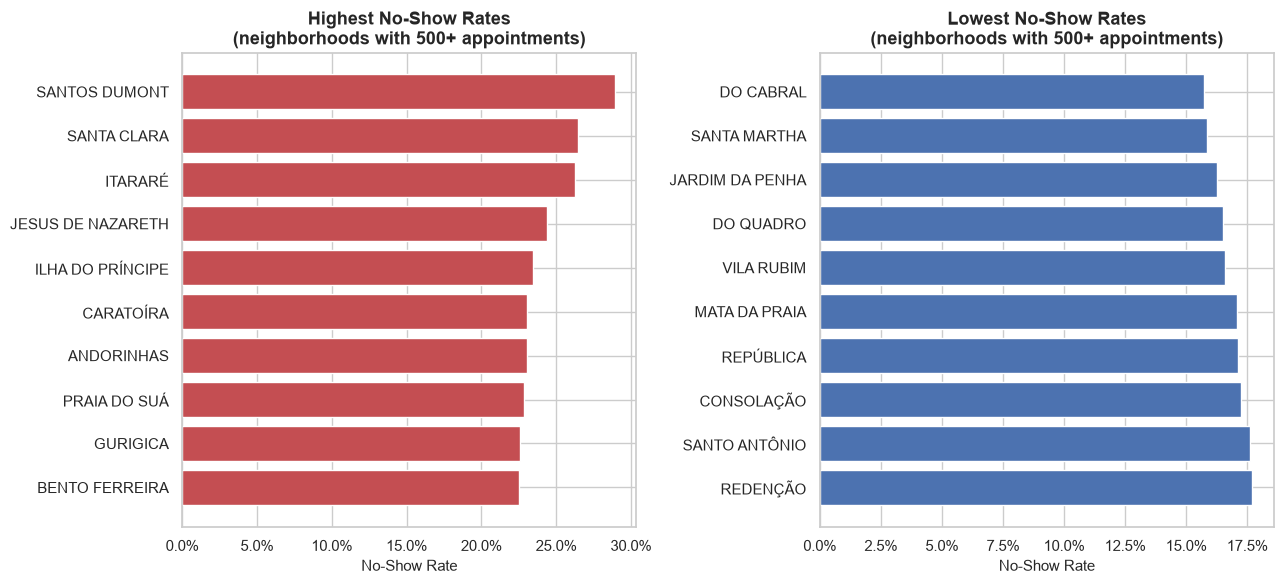

In [34]:
neighborhood_noshow = df.groupby('Neighbourhood')['No-show'].value_counts(normalize=True).unstack()['Yes']
neighborhood_counts = df['Neighbourhood'].value_counts()

neighborhood_summary = pd.DataFrame({
    'No-Show Rate': neighborhood_noshow,
    'Total_Appointments': neighborhood_counts
})

# Restrict to neighborhoods with at least 500 appointments so estimates are reasonably stable
reliable = neighborhood_summary[neighborhood_summary['Total_Appointments'] >= 500]

top10 = reliable.sort_values('No-Show Rate', ascending=False).head(10).sort_values('No-Show Rate')
bottom10 = reliable.sort_values('No-Show Rate').head(10).sort_values('No-Show Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].barh(top10.index, top10['No-Show Rate'], color='#C44E52')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title('Highest No-Show Rates\n(neighborhoods with 500+ appointments)')
axes[0].set_xlabel('No-Show Rate')

axes[1].barh(bottom10.index, bottom10['No-Show Rate'], color='#4C72B0')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Lowest No-Show Rates\n(neighborhoods with 500+ appointments)')
axes[1].set_xlabel('No-Show Rate')

plt.tight_layout()
plt.show()

Among neighborhoods with at least 500 appointments, chosen as a stability threshold, no-show rates range from about 15.7% (Do Cabral) to 28.9% (Santos Dumont), a meaningful spread of roughly 13 percentage points across the city. Smaller neighborhoods are excluded because their estimates are less stable, including one neighborhood with only 2 appointments and a 100% no-show rate.

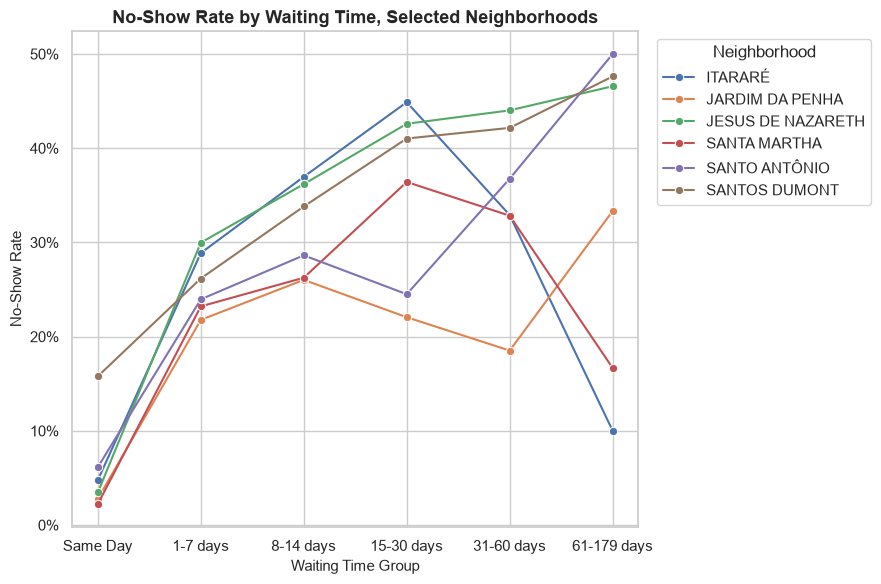

In [35]:
selected_neighborhoods = [
    'SANTOS DUMONT', 'ITARARÉ', 'JESUS DE NAZARETH',
    'SANTA MARTHA', 'JARDIM DA PENHA', 'SANTO ANTÔNIO'
]

neighborhood_waiting = (
    df[df['Neighbourhood'].isin(selected_neighborhoods)]
    .groupby(['Neighbourhood', 'Waiting_Group'], observed=True)['No-show']
    .value_counts(normalize=True)
    .unstack()['Yes']
    .reset_index()
    .rename(columns={'Yes': 'NoShowRate'})
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(
    data=neighborhood_waiting,
    x='Waiting_Group', y='NoShowRate', hue='Neighbourhood',
    marker='o', ax=ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('No-Show Rate by Waiting Time, Selected Neighborhoods')
ax.set_xlabel('Waiting Time Group')
ax.set_ylabel('No-Show Rate')
ax.legend(title='Neighborhood', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Comparing a handful of high and low-no-show neighborhoods across waiting-time groups shows that differences between neighborhoods persist even within similar waiting-time bands. Santos Dumont, which has the highest overall no-show rate among the selected neighborhoods, tends to remain above Santo Antônio and Jardim da Penha, which have lower overall rates, across most waiting-time levels. This suggests that waiting time alone does not fully explain the neighborhood differences. Other factors, such as distance, transportation access, or local clinic practices, could potentially contribute, but these factors are not available in the dataset and therefore cannot be directly evaluated.

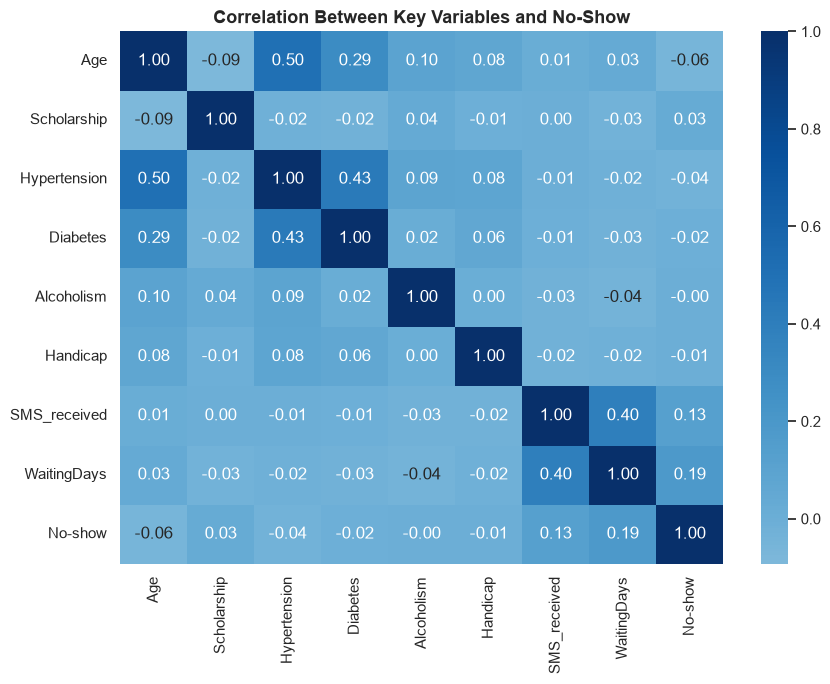

In [66]:
corr_cols = [
    'Age',
    'Scholarship',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'SMS_received',
    'WaitingDays'
]

corr_df = df[corr_cols + ['No-show']].copy()

corr_df['No-show'] = corr_df['No-show'].map({'No': 0, 'Yes': 1})

correlation = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    ax=ax
)

ax.set_title('Correlation Between Key Variables and No-Show')

plt.tight_layout()
plt.show()

The correlation heatmap provides a summary of the relationships examined throughout the EDA. WaitingDays shows the strongest relationship with no-show status among the variables included, while the remaining variables show relatively weaker associations. These correlations are descriptive and do not establish causation, but they provide a useful overview of which variables warrant further investigation.

## 8. Key Findings

This exploratory analysis examined factors associated with missed medical appointments. Several variables showed meaningful differences in no-show rates, while others showed little apparent association.

- **Waiting time** showed the strongest association with attendance. Same-day appointments had a no-show rate of just 4.6%, rising to 34.2% for appointments booked 31–60 days in advance. Patients who missed their appointment had a median wait of 11 days, versus 2 days for those who attended.
- **Age** was associated with attendance. Patients aged 18–29 had the highest no-show rate (~24.6%), compared to ~15–18% among patients 45 and older, suggesting younger adults are more likely to miss appointments.
- **SMS receipt** was associated with a *higher* raw no-show rate, but this reverses once waiting time is accounted for. SMS recipients showed *lower* no-show rates than non-recipients within the same waiting-time band. The raw association was substantially driven by the fact that SMS recipients have much longer average waits.
- **Neighborhood** showed meaningful variation, ranging from ~15.7% to ~28.9% among neighborhoods with reliable sample sizes. These differences persisted even within similar waiting-time groups, suggesting waiting time doesn't fully explain the pattern.
- **Scholarship status** showed a modest association (~23.7% vs ~19.8%) that persisted across age groups, ruling out age as the sole explanation, though the effect size is small.
- **Gender** showed little association with attendance (~20.3% for female patients vs ~20.0% for male patients).
- **Hypertension, diabetes, and alcoholism** showed relatively weak associations with attendance. **Handicap** showed a pattern of higher no-show rates at higher coded levels, but the highest levels (3 and 4) have only 13 and 3 observations respectively, making that pattern unreliable.
- **Appointment day of week** showed little association, with weekday no-show rates ranging narrowly from ~19.4% to ~21.2%.

## 9. Recommendations

These are practical suggestions based on the associations above, not guarantees, since the data is observational and several of these factors are intertwined (e.g. SMS and waiting time).

- **Add a reminder closer to the appointment date for long-lead-time bookings.** No-show risk rises sharply once waiting time exceeds ~7 days and stays elevated through the 31–60 day range. Within any given waiting-time band, patients who received an SMS reminder had a *lower* no-show rate than those who didn't, so expanding reminder coverage for these longer-wait appointments (e.g. a second reminder a few days before, not just at booking) is worth considering, particularly since these are also the patients currently least likely to get an SMS.
- **Target outreach at younger adult patients (18–29).** This group had the highest no-show rate (~24.6%) of any age band. A lighter-touch intervention (e.g. text-based rescheduling links, or reminders timed to when this group is more likely to check messages) could be tested against the current process.
- **Investigate the high-no-show neighborhoods operationally, not just statistically.** Santos Dumont and similar neighborhoods kept elevated no-show rates even after accounting for waiting time, suggesting something specific to those areas (transportation access, clinic hours, distance) rather than scheduling alone. This points to a follow-up: talk to clinic staff or patients in those neighborhoods rather than trying to explain it from this dataset alone.
- **Look deeper into the scholarship gap before acting on it.** The ~4-point gap persisted across age groups, but the dataset doesn't include income, distance, or transportation, the actual driver isn't identifiable here. Worth flagging for a follow-up study rather than acting on directly.
- **Treat day-of-week and most health conditions as lower priority.** These showed weak associations here, so operational effort is likely better spent on the waiting-time, age, and neighborhood patterns above.
- **For a future iteration:** the natural next step is a predictive model (e.g. logistic regression) that estimates no-show probability per appointment using these variables jointly, which would clarify how much each factor matters once the others are controlled for — this analysis only looked at variables one or two at a time.

## 10. Limitations

- This analysis identifies **associations, not causal relationships**. The dataset does not support claims that any individual factor directly causes patients to miss appointments.
- **SMS and waiting time are confounded.** SMS is never sent for same-day appointments, so isolating the effect of SMS itself would require a more careful design (e.g. only comparing appointments with similar waiting times, or a proper causal analysis) than simple exploratory grouping.
- **Small sample sizes** affect some subgroups, notably `Handicap` levels 2–4 and several low-volume neighborhoods; estimated rates for these groups are less stable and shouldn't be over-interpreted.
- **`Handicap` coding is ambiguous,** values range from 0–4, but the dataset documentation doesn't clarify what levels 2–4 specifically represent.
- **Minor data-quality issues** were identified and corrected: one appointment with `Age = -1`, and five appointments where the scheduled date fell after the appointment date. Both were converted to missing values given how rare they are.
- **Saturday/Sunday appointments** are too rare (39 and 0, respectively) to support any conclusion about weekend scheduling.

Overall, waiting time, age, SMS receipt (in combination with waiting time), and neighborhood appear to be the more promising variables for understanding appointment attendance, while gender, appointment day of week, and most individual health conditions show comparatively weak associations. These findings could inform a future predictive modeling project that formally evaluates which factors best predict no-shows.